In [1]:
import numpy as np
from scipy import fft, signal
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib.animation

from IPython.display import HTML, Image

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

 


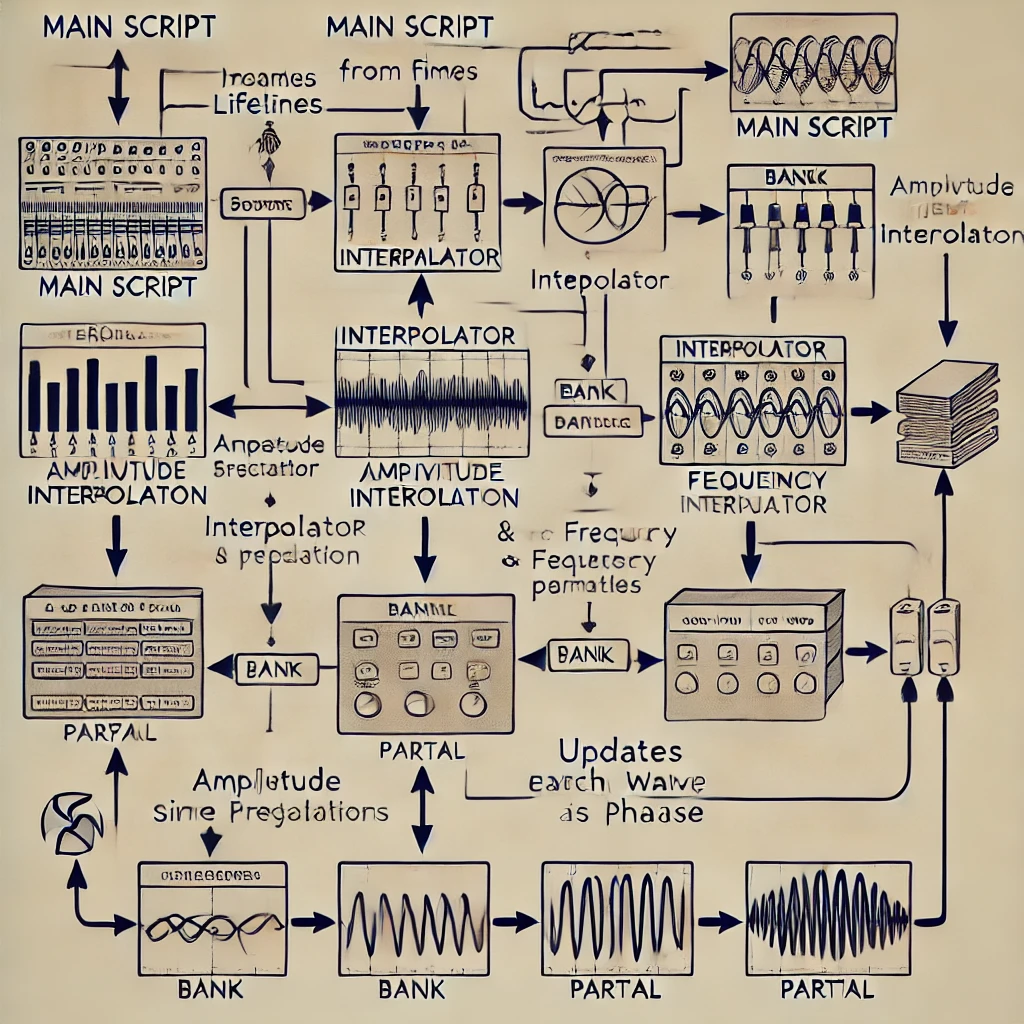

In [2]:
display(Image("../images/spectral_modeling/dall-e_spectral_synthesis.png",width=500))

<center> Our spectral synthesis algorithm according to DALL·E. </center>

-----

# Time-Domain Spectral Synthesis

Similar to the [partial tracking exercise](http://ringbuffer.org/sound_synthesis_introduction/Additive_Spectral/partial_tracking_exercise/),
this implementation is designed to help understand time-domain spectral synthesis.
There are more efficient ways to perform this kind of additive synthesis - especially in offline applications.
In this version, we will go sample by sample in the output signal, allowing us to inspect (and debug) every aspect.

This Python implementation is based on three classes and a nested loop.
The classes will be provided completely, alongside the basic structure of the loop.
Some gaps are left to fill. These gaps are marked with the <font color='red'>'[CODE]'</font> label.








-----

# Modules

In addition to the standard modules, we add sounddevice to play audio directly from python.
Based on PortAudio, this module works on all common operating systems.

```python
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import sounddevice as sd
```

The sounddevice moule can be installed with:

    $ pip install sounddevice

Make sure to have your virtual environment activated before installing.



-----

# The Classes



-----

## Partial Class

The partial class can be considered a *state machine* in the wider sense,
with the attributes amplitude, frequency and phase. It implements a step method, 
that increments the phase based on the frequency.
The **instantaneous amplitude** (the amplitude of a signal at a specific point in time) of this oscillator can be accessed with a dedicated method.

```python
#################################################################################
# Class for a single partial
#################################################################################

class partial:
    
    def __init__(self, fs):        
        self.fs = fs
                
        self.a=0
        self.f=0
        self.p=0
        
    # method for setting the partial parameters:    
    def set_values(self, f, a):
        self.f = f
        self.a = a

    # method to step one sample ahead with the recent frequency of the sine               
    def step(self):                
        self.p += 2*np.pi*self.f * (1/self.fs)
        self.p = self.p % (2*np.pi)
        
    # method for returning the instantaneous amplitude 
    # - based on the partial's parameters
    def get_value(self):        
        return self.a * np.sin(self.p)
```

-----

## Partial Bank Class

The parial bank holds a list of partials. 
It is basically a convinience-wrapper to manage all partials together.

```python
#################################################################################
# Class for the partial bank
#################################################################################

                
class bank:
        
    def __init__(self, fs, nPart):                
        self.nPart = nPart
        # the partial bank holds a list of partials
        self.partials = [partial(fs) for i in range(nPart)]

    # method to loop over all partials and sum their instantaneous amplitude:
    def get_sample(self):
        out = 0        
        for p in self.partials:            
            out += p.get_value()
            
        return out
            
    # method to step one sample ahead for every partial:                  
    def step(self):        
        for p in self.partials:            
            p.step()
    
    # method to set all partial values with two vectors:
    def set_partials(self,F,A):                
        for i in range(self.nPart):         
            self.partials[i].set_values(F[i], A[i])
```

----

<div class="alert alert-block alert-info"> <b>Try Out: </b> 
    Create a bank with 10 oscillators as harmonics and use it to generate a signal of 2 seconds length at 48 kHz.
</div>

-----

## Interpolator Class

We need to interpolate our partial parameter trajectories between the support points we get from the partial tracking matrices.
This class is a very simple linear interpolator.
It creates a linear slope between two frames with `nHop` samples and offers a method to get the values within the slope.

```python
#################################################################################
# Interpolator class
#################################################################################
            

class interpolator:

    def __init__(self, nHop):    
        self.nHop = nHop
        self.traj = np.zeros(nHop)
        
    # method to set new start (a) and end (b) values for the linear slope:
    def set_new(self, a,b):
        self.traj = np.linspace(a, b, self.nHop)
        
    # method to get the value of the linear slope at any position:
    def get_at(self, pos):        
        val = self.traj[pos]
        return val
```

------

# Preparations

Before we start with the main synthesis loop, we prepare all our input and output data.

## Loading Analysis Results

If a set of analysis results has been stored following the [partial tracking exercise](http://ringbuffer.org/sound_synthesis_introduction/Additive_Spectral/partial_tracking_exercise/),
it can be loaded with the following lines:

```python
#################################################################################
# Prepare Data
#################################################################################

# load matrices with partial trajectories
F = np.loadtxt('partial_frequencies.sms')
A = np.loadtxt('partial_amplitudes.sms')

# load analysis parameters
fs = int(np.loadtxt('params.sms')[0])
nHop = int(np.loadtxt('params.sms')[1])
```

In case the analysis was not successful, a set of analysis results can be downloaded here: [https://ringbuffer.org/download/spectral_modeling/](https://ringbuffer.org/download/spectral_modeling/)

---

## Synthesis Parameters and Objects

We can obtain the number of frames and the number of partials from the 
dimension of the data we have loaded:

```python
#################################################################################
# Get synthesis parameters from matrices
#################################################################################

# use the shape method to get number of frames and partials:
nFrames = A.shape[0]
nPart   = A.shape[1]

# allocate output vector:
y       = np.zeros(nHop*nFrames)

# list of interpolators for the partial amplitudes:
interpA =  [interpolator(nHop) for i in range(nPart)]
# list of interpolators for the partial freuencies:
interpF =  [interpolator(nHop) for i in range(nPart)]

# the oscillator-bank object:
ob      = bank(fs,nPart)
```

-----

# The Synthesis Loop

Similar to the analysis, our synthesis is a loop along the time axis, with a nested loop over the partials.
More precisely, this loop steps over every output sample. Whenever a new analysis frame is reached, the interpolators are set.

The following Unified Modeling Language (UML) sequence diagram visualizes the core loops and calls of this implementation:

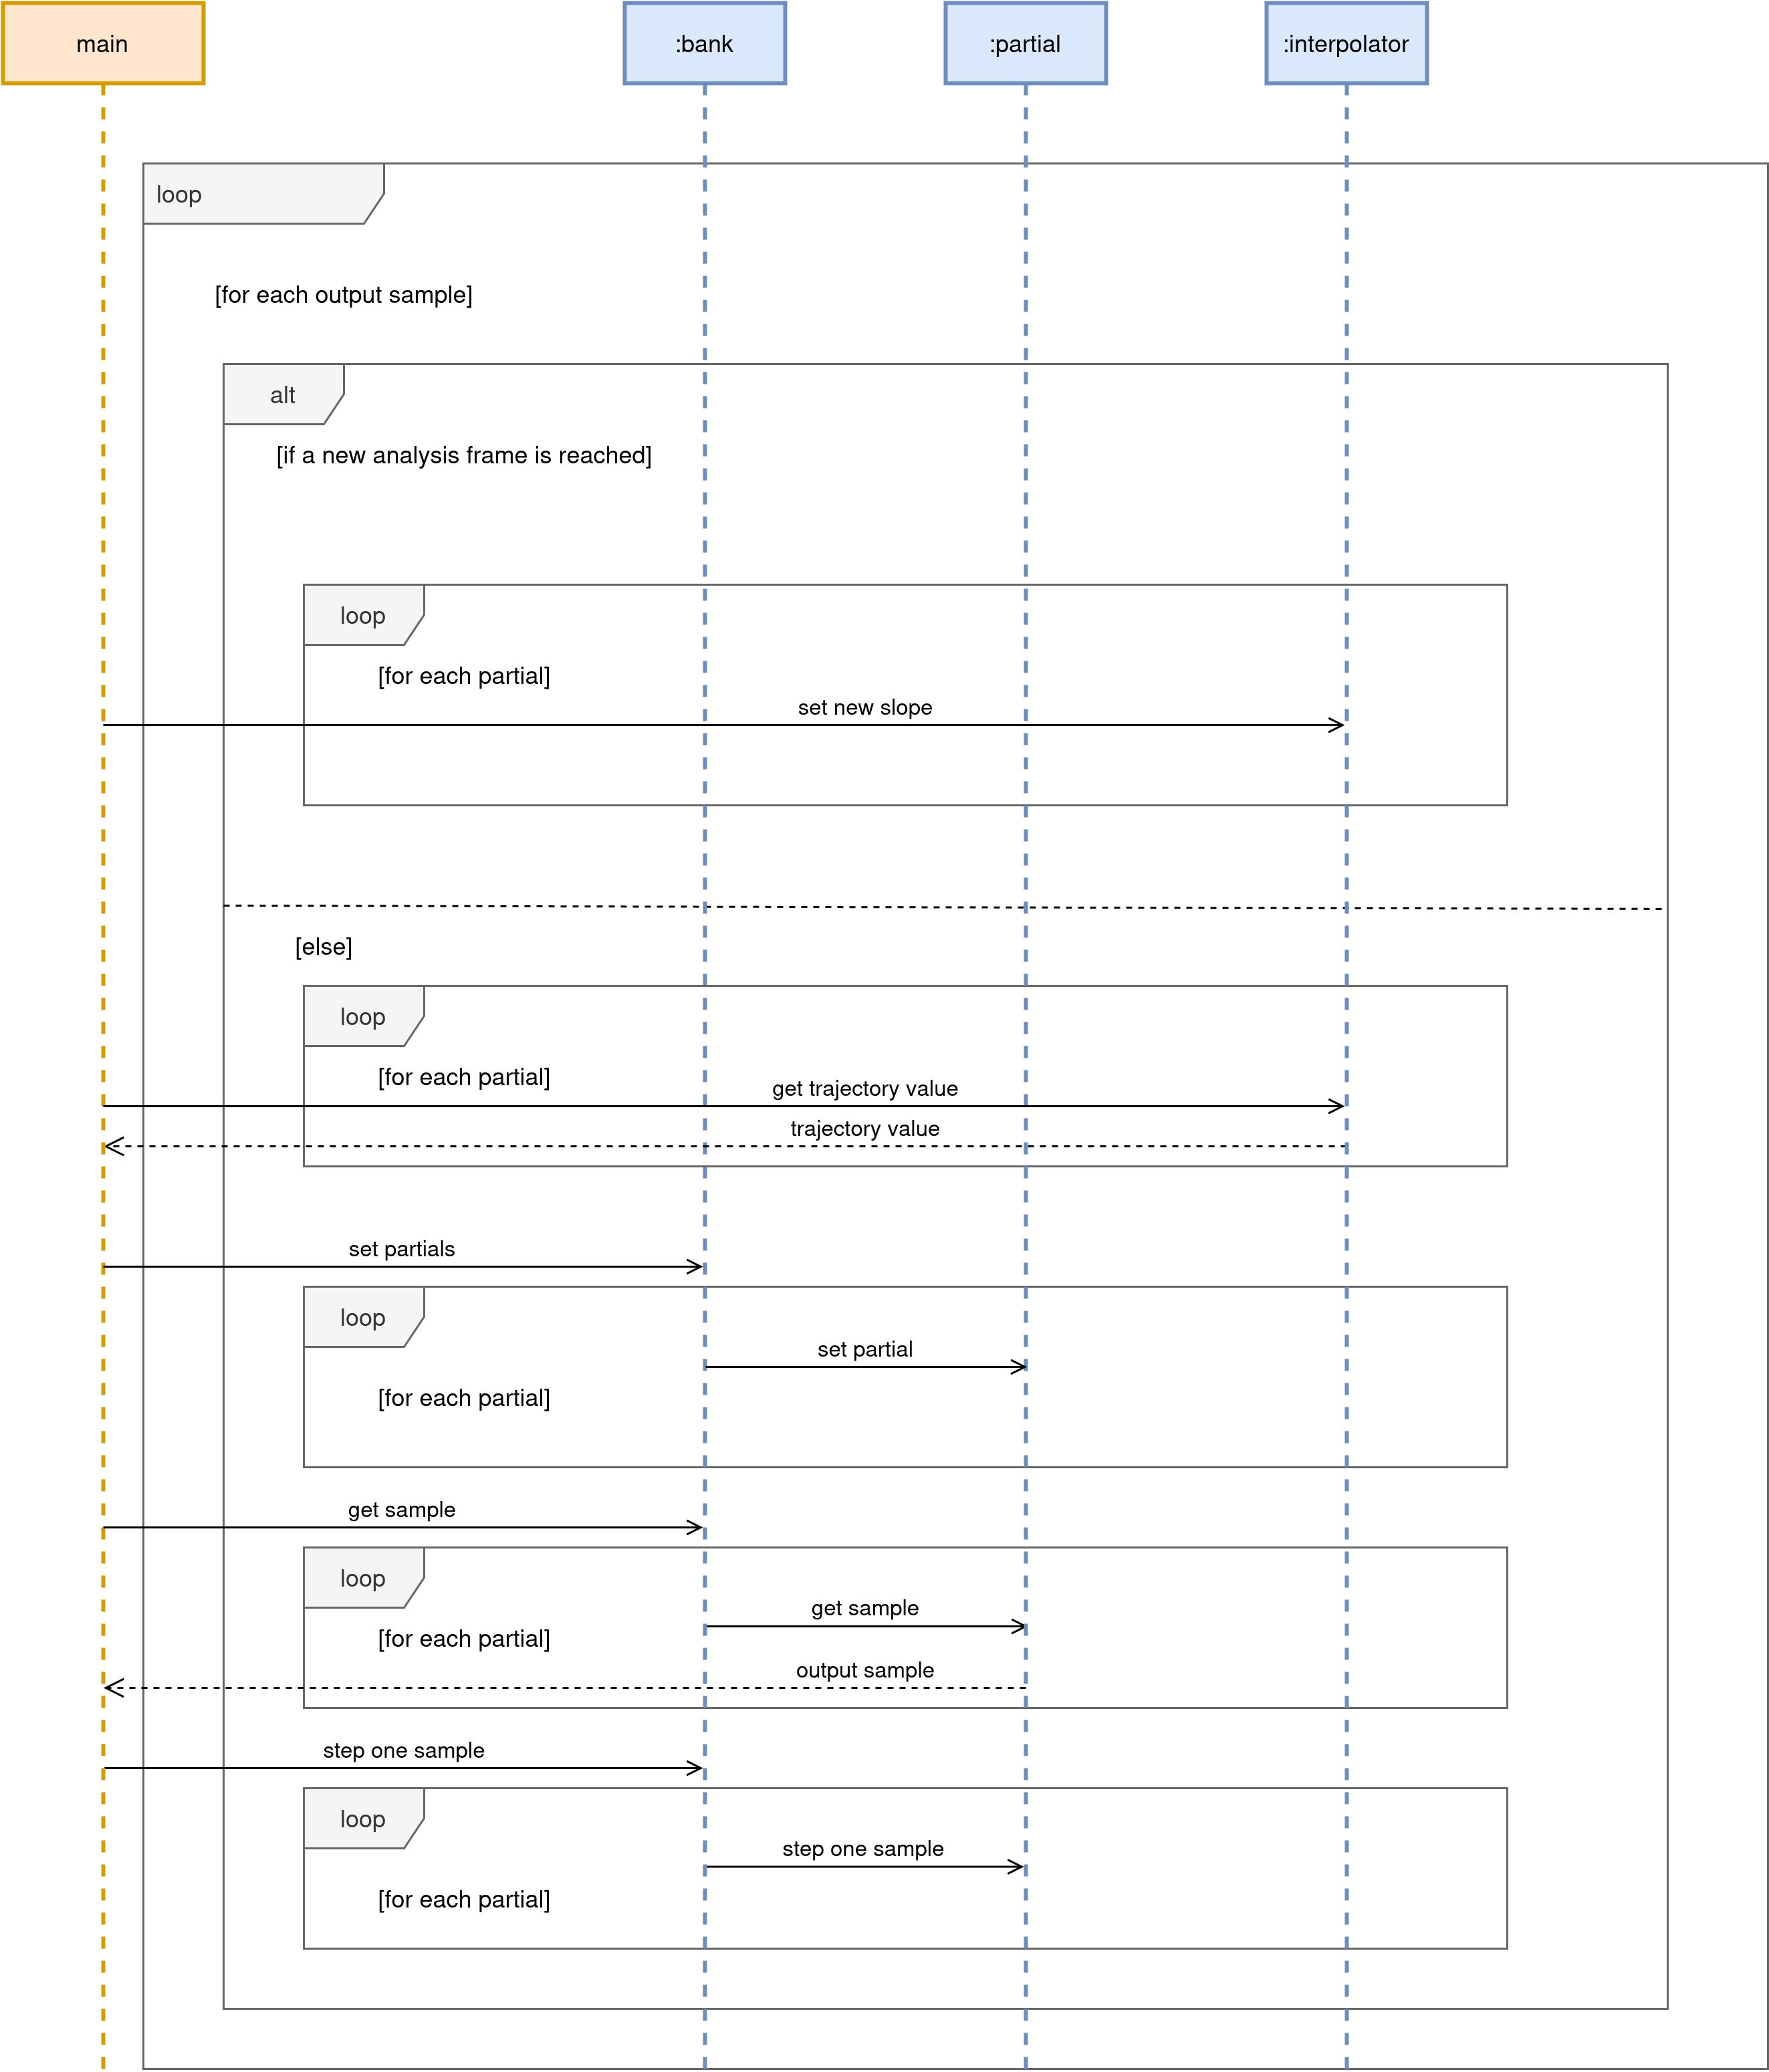

In [5]:
display(Image("../images/spectral_modeling/spectral_synthesis_uml.png"))


-----


```python
#################################################################################
# Loop over each output sample
#################################################################################

# A counter over the analysis frames:
# - starting at '1" for interpolation
frameIdx   = 1

# A counter in the synthesis domain
frameCounter = nHop

# LOOP over all output samples:
for sample_idx in range(len(y)):          
    
    # IF we reach a new analysis frame
    if frameCounter >= nHop:

        # get last frame's partial values:
        lastA = '[CODE]'
        lastF = '[CODE]'
        
        # get this frame's partial values:
        thisA = '[CODE]'                
        thisF = '[CODE]'
       
        # LOOP over all synthesis frames:
        for partCount in range(nPart):
            # set interpolator for for all partial trajectories:
            interpA[partCount].set_new('[CODE]')
            interpF[partCount].set_new('[CODE]')
                        
        # rest the frame counter:
        frameCounter  = 0   
        # increase the frame index
        frameIdx   += 1

    # stop this loop if no analysis frames are left:
    if frameIdx>=nFrames:
        break
    
    # get the partial trajectory values from the interpolators:
    aList = '[CODE]'
    fList = '[CODE]'

    # set the oscillators (partials):
    ob.set_partials('[CODE]')
    
    # get this output value from all partials (via the oscillator bank):
    y[sample_idx] = '[CODE]'
    
    # step one sample ahead with all partials (via the oscillator bank):
    '[CODE]'

    # increase the frame counter:
    frameCounter += 1


sd.play(y,fs)
```

-----

# Manipulation Exercises

Sinusoidal modeling has a couple of strenghts:

- It reduces the data of a stored sound significantly.
- It allows *limitless* means of manipulation.

The following exercises show how we can manipulate a sound using the analysis-synthesis approach:

<div class="alert alert-block alert-info"> <b>1) Pitch Shift: </b> 
Change the pitch of the re-synthesis without affecting the duration.
</div>


<div class="alert alert-block alert-info"> <b>2) Time Stretch / Shrink: </b> 
Change the duration of the re-synthesis without affecting the pitch.
</div>


<div class="alert alert-block alert-info"> <b>3) Partial Selection: </b> 
Resynthesize the sound with a limited set of partials and compare the reults.
</div>


<div class="alert alert-block alert-info"> <b>4) Partial Manipulation: </b> 
Change the timbre of the sound by changing the weight of the parials.
</div>

